In [ ]:
!ls

images.zip  sample_data


In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define source (local folder) and destination (Drive folder)
# Replace 'your_data_folder' with the actual name of your uploaded folder
source_path = '/content/images.zip'
destination_path = '/content/drive/MyDrive/colab_data_backup'

# 3. Create the destination folder on Drive if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# 4. Copy the folder to Drive (-r copies all sub-folders and files)
!cp -r "{source_path}" "{destination_path}"

print(f"✅ Backup complete! Your data is safe at: {destination_path}")


Mounted at /content/drive
✅ Backup complete! Your data is safe at: /content/drive/MyDrive/colab_data_backup


In [ ]:
# List the contents of your new Drive folder to verify
!ls "{destination_path}"


images.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Now point your code to the persistent Drive path
data_dir = '/content/drive/MyDrive/colab_data_backup'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip images.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/train/Jackson_Pollock/Jackson_Pollock_9.jpg  
   creating: images/train/Jan_van_Eyck/
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_10.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_11.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_12.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_14.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_15.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_16.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_17.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_18.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_20.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_22.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_23.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_24.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyck_25.jpg  
  inflating: images/train/Jan_van_Eyck/Jan_van_Eyc

In [ ]:
import pandas as pd

df = pd.read_csv("metadata.csv")
print(df.head())

                                      image_path           artist  \
0   train/Albrecht_Du_rer/Albrecht_Du_rer_10.jpg  Albrecht Du rer   
1  train/Albrecht_Du_rer/Albrecht_Du_rer_100.jpg  Albrecht Du rer   
2  train/Albrecht_Du_rer/Albrecht_Du_rer_101.jpg  Albrecht Du rer   
3  train/Albrecht_Du_rer/Albrecht_Du_rer_102.jpg  Albrecht Du rer   
4  train/Albrecht_Du_rer/Albrecht_Du_rer_103.jpg  Albrecht Du rer   

         style  year   price  split  
0  Renaissance  1928  123360  train  
1  Renaissance  1869  116280  train  
2  Renaissance  1904  120480  train  
3  Renaissance  1916  121920  train  
4  Renaissance  1905  120599  train  


In [ ]:
print(df.columns)
print(df["split"].value_counts())
print(df["artist"].value_counts())

Index(['image_path', 'artist', 'style', 'year', 'price', 'split'], dtype='object')
split
train    5997
test      835
Name: count, dtype: int64
artist
Vincent van Gogh             722
Edgar Degas                  575
Pablo Picasso                359
Pierre-Auguste Renoir        275
Albrecht Du rer              270
Paul Gauguin                 255
Francisco Goya               236
Rembrandt                    215
Alfred Sisley                213
Titian                       209
Marc Chagall                 196
Rene Magritte                159
Amedeo Modigliani            158
Paul Klee                    153
Henri Matisse                152
Andy Warhol                  147
Mikhail Vrubel               139
Sandro Botticelli            136
Leonardo da Vinci            116
Peter Paul Rubens            115
Salvador Dali                112
Hieronymus Bosch             112
Pieter Bruegel               110
Kazimir Malevich             103
Giotto di Bondone             97
Frida Kahlo              

In [ ]:
import os

BASE_DIR = "images"

def check_paths(df):
    missing = []
    for path in df["image_path"]:
        full_path = os.path.join(BASE_DIR, path)
        if not os.path.exists(full_path):
            missing.append(full_path)
    return missing

missing_files = check_paths(df)
print("Missing files:", len(missing_files))

Missing files: 0


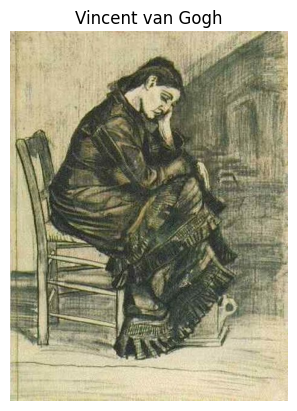

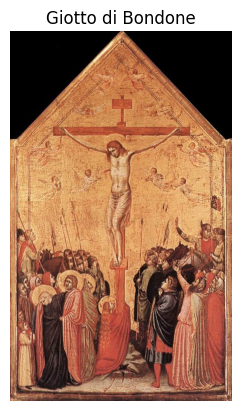

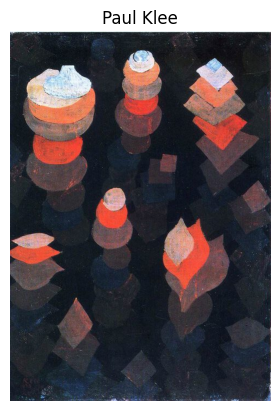

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

sample = df.sample(3)

for _, row in sample.iterrows():
    img_path = os.path.join("images", row["image_path"])
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(row["artist"])
    plt.axis("off")
    plt.show()

In [ ]:
print(os.path.exists(r"/content/images/test/Albrecht_Du_rer/Albrecht_Du_rer_1.jpg"))

True


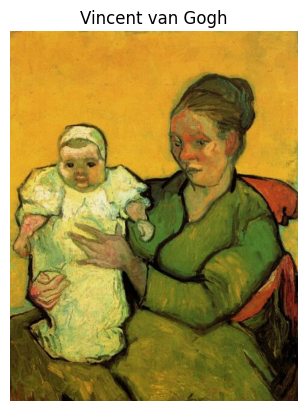

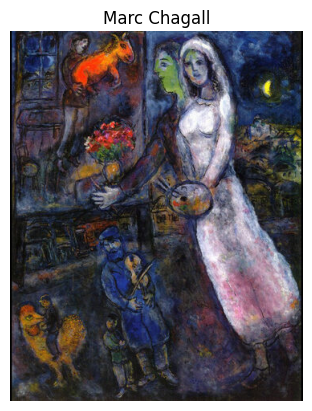

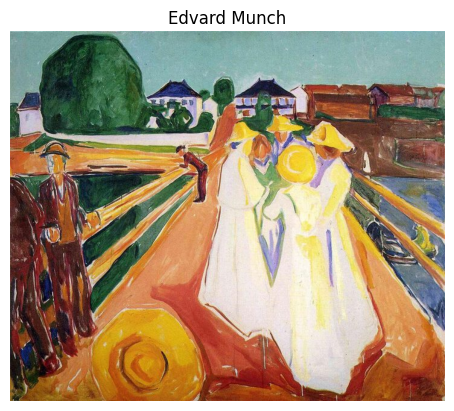

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

sample = df.sample(3)

for _, row in sample.iterrows():
    img_path = os.path.join("images", row["image_path"])
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(row["artist"])
    plt.axis("off")
    plt.show()

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class ArtDataset(Dataset):
    def __init__(self, df, split, transform=None):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join("images", row["image_path"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = row["artist"]   # we’ll encode later

        return image, label

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # 🔥 ADD THESE
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
train_dataset = ArtDataset(df, split="train", transform=transform)
val_dataset   = ArtDataset(df, split="validation", transform=transform)
test_dataset  = ArtDataset(df, split="test", transform=transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)   # should be [batch, 3, 224, 224]
print(labels[:5])

torch.Size([16, 3, 224, 224])
('Vincent van Gogh', 'Eugene Delacroix', 'Edgar Degas', 'Leonardo da Vinci', 'Kazimir Malevich')


In [ ]:
train_df = df[df["split"] == "train"].reset_index(drop=True)

In [ ]:
from collections import defaultdict

artist_groups = defaultdict(list)

for idx, row in train_df.iterrows():
    artist_groups[row["artist"]].append(row["image_path"])

In [ ]:
import random

pairs = []

for artist in artists:
    images = artist_groups[artist]

    if len(images) < 2:
        continue

    # POSITIVE pairs
    for i in range(len(images) - 1):
        pairs.append((images[i], images[i+1], 1))

    # 🔥 MORE NEGATIVE PAIRS
    for _ in range(len(images)):   # same number as positives
        other_artist = random.choice([a for a in artists if a != artist])
        img1 = random.choice(images)
        img2 = random.choice(artist_groups[other_artist])
        pairs.append((img1, img2, 0))

In [ ]:
print("Total pairs:", len(pairs))
print(pairs[:5])
labels = [p[2] for p in pairs]
print("Positive:", labels.count(1))
print("Negative:", labels.count(0))

Total pairs: 11944
[('train/Albrecht_Du_rer/Albrecht_Du_rer_10.jpg', 'train/Albrecht_Du_rer/Albrecht_Du_rer_100.jpg', 1), ('train/Albrecht_Du_rer/Albrecht_Du_rer_100.jpg', 'train/Albrecht_Du_rer/Albrecht_Du_rer_101.jpg', 1), ('train/Albrecht_Du_rer/Albrecht_Du_rer_101.jpg', 'train/Albrecht_Du_rer/Albrecht_Du_rer_102.jpg', 1), ('train/Albrecht_Du_rer/Albrecht_Du_rer_102.jpg', 'train/Albrecht_Du_rer/Albrecht_Du_rer_103.jpg', 1), ('train/Albrecht_Du_rer/Albrecht_Du_rer_103.jpg', 'train/Albrecht_Du_rer/Albrecht_Du_rer_106.jpg', 1)]
Positive: 5947
Negative: 5997


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SiameseDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(os.path.join("images", img1_path)).convert("RGB")
        img2 = Image.open(os.path.join("images", img2_path)).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [ ]:
siamese_dataset = SiameseDataset(pairs, transform=transform)

In [ ]:
from torch.utils.data import DataLoader

siamese_loader = DataLoader(siamese_dataset, batch_size=16, shuffle=True)

In [ ]:
img1, img2, label = next(iter(siamese_loader))

print(img1.shape)   # [batch, 3, 224, 224]
print(img2.shape)
print(label[:5])

torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
tensor([1, 0, 0, 0, 1])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()

        self.base_model = models.resnet18(pretrained=True)

        # remove last layer
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, 128)

    import torch.nn.functional as F

    def forward_once(self, x):
        x = self.base_model(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, img1, img2):
        output1 = self.forward_once(img1)
        output2 = self.forward_once(img2)
        return output1, output2

In [ ]:
model = SiameseNetwork()

In [ ]:
img1, img2, label = next(iter(siamese_loader))

out1, out2 = model(img1, img2)

print(out1.shape)
print(out2.shape)

torch.Size([16, 128])
torch.Size([16, 128])


In [ ]:
import torch.nn.functional as F

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        distance = F.pairwise_distance(output1, output2)

        loss = torch.mean(
            label * torch.pow(distance, 2) +
            (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)
        )

        return loss

In [ ]:
criterion = ContrastiveLoss()

In [ ]:
img1, img2, label = next(iter(siamese_loader))

# convert label to float tensor
label = label.float()

out1, out2 = model(img1, img2)

loss = criterion(out1, out2, label)

print("Loss:", loss.item())

Loss: 0.45049187541007996


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SiameseNetwork(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [ ]:
val_df = df[df["split"] == "validation"].reset_index(drop=True)

In [ ]:
val_pairs = pairs[:1000]  # quick method (or generate properly)

val_dataset = SiameseDataset(val_pairs, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
train_losses = []
val_losses = []

In [ ]:
from tqdm import tqdm

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(siamese_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for i, (img1, img2, label) in enumerate(loop):

        img1, img2 = img1.to(device), img2.to(device)
        label = label.float().to(device)

        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # 🔥 Batch-wise update (live)
        loop.set_postfix(batch_loss=loss.item())

    train_loss = total_loss / len(siamese_loader)
    train_losses.append(train_loss)

    # 🔥 VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2 = img1.to(device), img2.to(device)
            label = label.float().to(device)

            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ✅ Epoch summary (clean)
    print(f"\nEpoch {epoch+1} Summary → Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n")

Epoch 1/15: 100%|██████████| 747/747 [04:49<00:00,  2.58it/s, batch_loss=0.351]



Epoch 1 Summary → Train Loss: 0.2495 | Val Loss: 0.2363



Epoch 2/15: 100%|██████████| 747/747 [04:50<00:00,  2.57it/s, batch_loss=0.252]



Epoch 2 Summary → Train Loss: 0.2519 | Val Loss: 0.2156



Epoch 3/15: 100%|██████████| 747/747 [04:51<00:00,  2.56it/s, batch_loss=0.212]


...


Epoch 13 Summary → Train Loss: 0.2360 | Val Loss: 0.1606



Epoch 14/15: 100%|██████████| 747/747 [04:50<00:00,  2.57it/s, batch_loss=0.244]



Epoch 14 Summary → Train Loss: 0.2318 | Val Loss: 0.1706



Epoch 15/15: 100%|██████████| 747/747 [04:50<00:00,  2.57it/s, batch_loss=0.146]



Epoch 15 Summary → Train Loss: 0.2283 | Val Loss: 0.1624



In [ ]:
torch.save(model.state_dict(), "siamese_model_10epochs.pth")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
model = SiameseNetwork()
model.load_state_dict(torch.load("siamese_model_10epochs.pth"))
model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
test_df = df[df["split"] == "test"].reset_index(drop=True)

from collections import defaultdict
import random

artist_groups_test = defaultdict(list)

for _, row in test_df.iterrows():
    artist_groups_test[row["artist"]].append(row["image_path"])

test_pairs = []

artists = list(artist_groups_test.keys())

for artist in artists:
    images = artist_groups_test[artist]

    if len(images) < 2:
        continue

    # positive
    for i in range(len(images) - 1):
        test_pairs.append((images[i], images[i+1], 1))

    # negative
    other_artist = random.choice([a for a in artists if a != artist])
    test_pairs.append((
        random.choice(images),
        random.choice(artist_groups_test[other_artist]),
        0
    ))

In [ ]:
test_dataset = SiameseDataset(test_pairs, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model.eval()
test_loss = 0

with torch.no_grad():
    for img1, img2, label in test_loader:

        img1, img2 = img1.to(device), img2.to(device)
        label = label.float().to(device)

        out1, out2 = model(img1, img2)

        loss = criterion(out1, out2, label)
        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.2574


In [ ]:
thresholds = [0.3, 0.5, 0.7, 1.0]

for t in thresholds:
    correct = 0
    total = 0

    with torch.no_grad():
       threshold = 0.8   # 🔥 try 0.75 or 0.8

correct = 0
total = 0

with torch.no_grad():
    for img1, img2, label in test_loader:

        img1, img2 = img1.to(device), img2.to(device)
        label = label.float().to(device)

        out1, out2 = model(img1, img2)

        dist = torch.nn.functional.pairwise_distance(out1, out2)

        preds = (dist < threshold).float()

        correct += (preds == label).sum().item()
        total += label.size(0)

accuracy = correct / total

print(f"Final Accuracy (threshold={threshold}) → {accuracy:.4f}")

Final Accuracy (threshold=0.8) → 0.9233


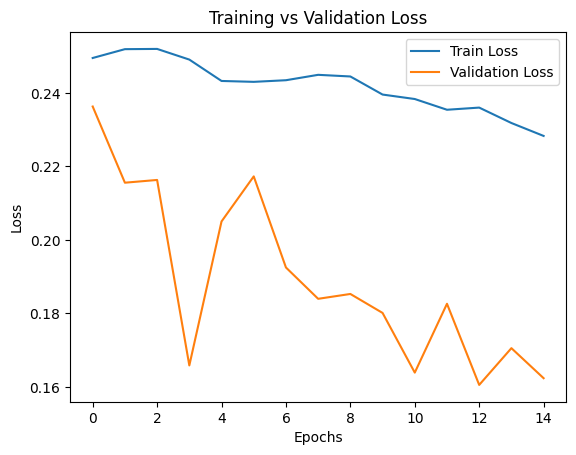

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

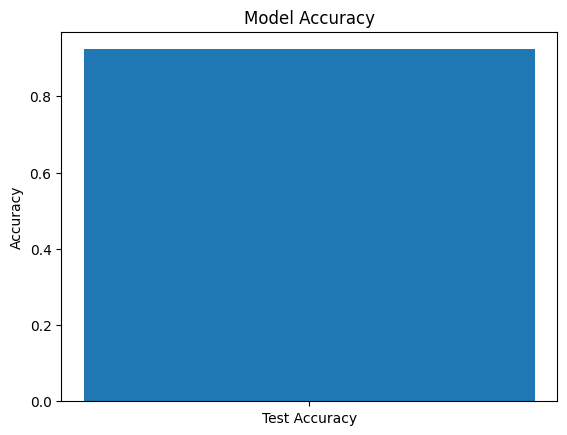

In [ ]:
accuracies = [accuracy]  # single value

plt.figure()
plt.bar(["Test Accuracy"], accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.show()

In [ ]:
similar_dist = []
different_dist = []

with torch.no_grad():
    for img1, img2, label in test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        label = label.float().to(device)

        out1, out2 = model(img1, img2)
        dist = torch.nn.functional.pairwise_distance(out1, out2)

        for d, l in zip(dist, label):
            if l == 1:
                similar_dist.append(d.item())
            else:
                different_dist.append(d.item())

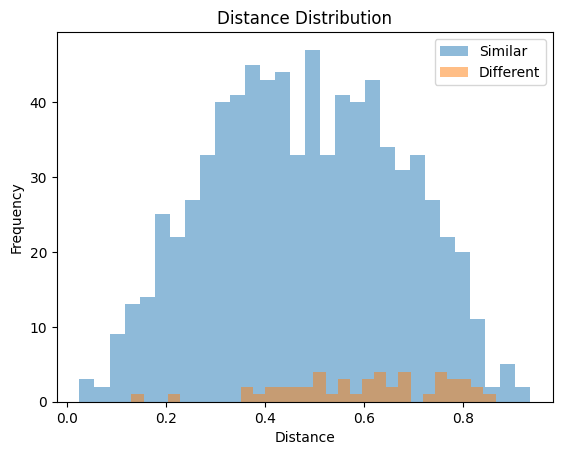

In [ ]:
plt.figure()
plt.hist(similar_dist, bins=30, alpha=0.5, label="Similar")
plt.hist(different_dist, bins=30, alpha=0.5, label="Different")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distance Distribution")
plt.legend()
plt.show()

In [ ]:
lstm_df = df[["artist", "year", "price"]].copy()
lstm_df = lstm_df.sort_values(by=["artist", "year"])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
lstm_df["price"] = scaler.fit_transform(lstm_df[["price"]])

In [ ]:
import numpy as np

sequence_length = 3

X = []
y = []

for artist in lstm_df["artist"].unique():
    artist_data = lstm_df[lstm_df["artist"] == artist]["price"].values

    if len(artist_data) > sequence_length:
        for i in range(len(artist_data) - sequence_length):
            X.append(artist_data[i:i+sequence_length])
            y.append(artist_data[i+sequence_length])

X = np.array(X)
y = np.array(y)

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
print(X.shape)
print(y.shape)

(6682, 3, 1)
(6682,)


In [ ]:
import torch
import torch.nn as nn

class PriceLSTM(nn.Module):
    def __init__(self):
        super(PriceLSTM, self).__init__()

        self.lstm1 = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)

        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        self.fc1 = nn.Linear(32, 16)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        # Take last timestep
        out = out[:, -1, :]

        out = self.fc1(out)
        out = self.relu(out)

        out = self.fc2(out)

        return out

In [ ]:
model_lstm = PriceLSTM().to(device)

In [ ]:
criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

In [ ]:
epochs = 51

for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        optimizer_lstm.zero_grad()

        outputs = model_lstm(X_batch)
        loss = criterion_lstm(outputs.squeeze(), y_batch)

        loss.backward()
        optimizer_lstm.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 0, Loss: 0.0001
Epoch 5, Loss: 0.0001
Epoch 10, Loss: 0.0001
Epoch 15, Loss: 0.0001
Epoch 20, Loss: 0.0001
Epoch 25, Loss: 0.0001
Epoch 30, Loss: 0.0001
Epoch 35, Loss: 0.0001
Epoch 40, Loss: 0.0001
Epoch 45, Loss: 0.0001
Epoch 50, Loss: 0.0001


In [ ]:
model_lstm.eval()

with torch.no_grad():
    predictions = model_lstm(X_test).squeeze()

    loss = criterion_lstm(predictions, y_test)

print(f"Test MSE: {loss.item():.4f}")

Test MSE: 0.0005


In [ ]:
import math

rmse = math.sqrt(loss.item())
print(f"RMSE: {rmse:.4f}")

RMSE: 0.0223


In [ ]:
rmse_actual = scaler.inverse_transform([[rmse]])[0][0]
print("RMSE in actual price:", rmse_actual)

RMSE in actual price: 50653.00895381682


In [ ]:
predictions_np = predictions.cpu().numpy().reshape(-1, 1)
y_test_np = y_test.cpu().numpy().reshape(-1, 1)

predictions_actual = scaler.inverse_transform(predictions_np)
y_actual = scaler.inverse_transform(y_test_np)

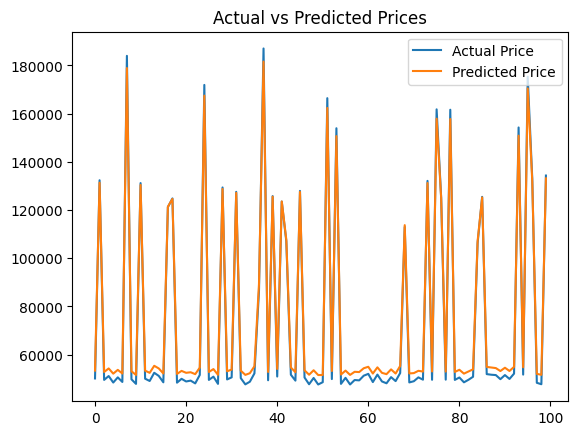

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_actual[:100], label="Actual Price")
plt.plot(predictions_actual[:100], label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [ ]:
torch.save(model_lstm.state_dict(), "lstm_model.pth")
print("LSTM model saved successfully!")

LSTM model saved successfully!


In [ ]:
import torch
import torch.nn as nn

class FusionModel(nn.Module):
    def __init__(self, cnn_model, lstm_model):
        super(FusionModel, self).__init__()

        self.cnn = cnn_model
        self.lstm = lstm_model

        # Freeze CNN if needed
        # for param in self.cnn.parameters():
        #     param.requires_grad = False

        self.fc_fusion = nn.Sequential(
            nn.Linear(2, 128),   # 🔥 FIXED
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, img1, img2, sequence):
        # CNN output
        out1, out2 = self.cnn(img1, img2)

        # distance as feature
        dist = torch.nn.functional.pairwise_distance(out1, out2).unsqueeze(1)

        # LSTM output
        lstm_out = self.lstm(sequence)

        # Fusion
        combined = torch.cat((dist, lstm_out), dim=1)

        output = self.fc_fusion(combined)

        return output

In [ ]:
fusion_model = FusionModel(model, model_lstm).to(device)

In [ ]:
criterion_fusion = nn.MSELoss()
optimizer_fusion = torch.optim.Adam(fusion_model.parameters(), lr=0.0005)

In [ ]:
from tqdm import tqdm

epochs = 8

for epoch in range(epochs):
    fusion_model.train()
    total_loss = 0

    loop = tqdm(zip(siamese_loader, loader), total=len(siamese_loader))

    for (img1, img2, label), (seq, price) in loop:

        img1, img2 = img1.to(device), img2.to(device)
        seq = seq.to(device)
        price = price.to(device)

        optimizer_fusion.zero_grad()

        # 🔥 Forward pass
        out1, out2 = fusion_model.cnn(img1, img2)
        dist = torch.nn.functional.pairwise_distance(out1, out2).unsqueeze(1)

        lstm_out = fusion_model.lstm(seq)

        # 🔥 FIX batch mismatch (IMPORTANT)
        min_size = min(dist.size(0), lstm_out.size(0))
        dist = dist[:min_size]
        lstm_out = lstm_out[:min_size]
        price = price[:min_size]

        # 🔥 Fusion
        combined = torch.cat((dist, lstm_out), dim=1)
        output = fusion_model.fc_fusion(combined)

        # 🔥 Loss
        loss = criterion_fusion(output.squeeze(), price)

        loss.backward()
        optimizer_fusion.step()

        total_loss += loss.item()

        # 🔥 Live progress
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(batch_loss=loss.item())

    # ✅ Average loss per epoch
    avg_loss = total_loss / len(siamese_loader)

    print(f"\n✅ Epoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f}\n")

Epoch [1/8]:  56%|█████▌    | 418/747 [02:43<02:08,  2.55it/s, batch_loss=0.000133]



✅ Epoch 1 Completed | Avg Loss: 0.0004



Epoch [2/8]:  56%|█████▌    | 418/747 [02:43<02:08,  2.55it/s, batch_loss=0.000636]



✅ Epoch 2 Completed | Avg Loss: 0.0003



Epoch [3/8]:  56%|█████▌    | 418/747 [02:44<02:09,  2.54it/s, batch_loss=0.000447]


...


✅ Epoch 6 Completed | Avg Loss: 0.0002



Epoch [7/8]:  56%|█████▌    | 418/747 [02:45<02:10,  2.53it/s, batch_loss=0.000372]



✅ Epoch 7 Completed | Avg Loss: 0.0002



Epoch [8/8]:  56%|█████▌    | 418/747 [02:53<02:16,  2.41it/s, batch_loss=0.000145]


✅ Epoch 8 Completed | Avg Loss: 0.0002



In [ ]:
torch.save(fusion_model.state_dict(), "fusion_model.pth")
print("Fusion model saved successfully!")

Fusion model saved successfully!


In [ ]:
fusion_model.eval()

total_loss = 0

with torch.no_grad():
    for (img1, img2, label), (seq, price) in zip(siamese_loader, loader):

        img1, img2 = img1.to(device), img2.to(device)
        seq = seq.to(device)
        price = price.to(device)

        # CNN
        out1, out2 = fusion_model.cnn(img1, img2)
        dist = torch.nn.functional.pairwise_distance(out1, out2).unsqueeze(1)

        # LSTM
        lstm_out = fusion_model.lstm(seq)

        # 🔥 Fix mismatch
        min_size = min(dist.size(0), lstm_out.size(0))
        dist = dist[:min_size]
        lstm_out = lstm_out[:min_size]
        price = price[:min_size]

        combined = torch.cat((dist, lstm_out), dim=1)
        output = fusion_model.fc_fusion(combined)

        loss = criterion_fusion(output.squeeze(), price)
        total_loss += loss.item()

avg_loss = total_loss / len(siamese_loader)

print(f"Fusion Model Test Loss: {avg_loss:.4f}")

Fusion Model Test Loss: 0.0004


In [ ]:
import math

rmse = math.sqrt(avg_loss)
print(f"Fusion RMSE: {rmse:.4f}")

Fusion RMSE: 0.0204


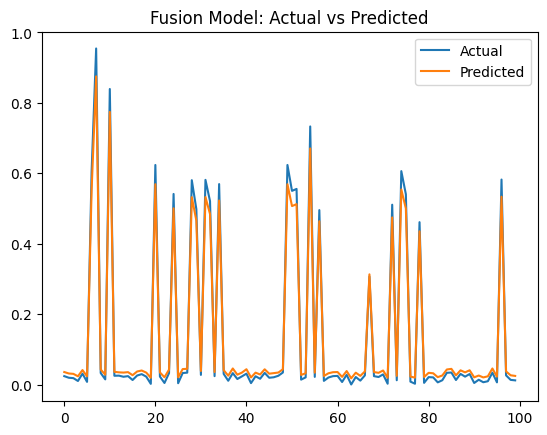

In [ ]:
import matplotlib.pyplot as plt

fusion_model.eval()

preds = []
actual = []

with torch.no_grad():
    for (img1, img2, label), (seq, price) in zip(siamese_loader, loader):

        img1, img2 = img1.to(device), img2.to(device)
        seq = seq.to(device)
        price = price.to(device)

        out1, out2 = fusion_model.cnn(img1, img2)
        dist = torch.nn.functional.pairwise_distance(out1, out2).unsqueeze(1)

        lstm_out = fusion_model.lstm(seq)

        min_size = min(dist.size(0), lstm_out.size(0))
        dist = dist[:min_size]
        lstm_out = lstm_out[:min_size]
        price = price[:min_size]

        combined = torch.cat((dist, lstm_out), dim=1)
        output = fusion_model.fc_fusion(combined)

        preds.extend(output.squeeze().cpu().numpy())
        actual.extend(price.cpu().numpy())

plt.figure()
plt.plot(actual[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.legend()
plt.title("Fusion Model: Actual vs Predicted")
plt.show()